## 1. What Is SSMS?

**SSMS (SQL Server Management Studio)** is a graphical client application used to manage, configure, and query Microsoft SQL Server. It is **not** the database engine itself — it's the tool you use to interact with the engine: browsing databases, writing and running SQL queries, creating tables, and managing server settings, all through a visual interface instead of the command line.


## 2. SQL Server vs. SSMS — Background Service vs. Connect Service

This distinction is easy to blur, so it's worth being precise about it:

| | SQL Server | SSMS |
|---|---|---|
| What it is | The actual database engine — the software that stores, processes, and serves data | A client tool that connects *to* that engine |
| How it runs | As a **background Windows service**, running continuously whether or not anyone is using it | A regular application you open, use, and close |
| Analogy | A running server, doing the actual work | A remote control that connects to that server |

In short: **SQL Server is the "Background Service"** — it runs constantly in the background, independent of any specific user session. **SSMS is the "Connect Service"** — you open it specifically to connect to that already-running SQL Server instance, inspect it, and issue commands to it. Closing SSMS doesn't stop SQL Server; the engine keeps running as a service regardless.

## 3. Installing SSMS

SSMS is a free tool distributed by Microsoft, independent of SQL Server itself (they're versioned and released separately — SSMS 20.2 was the version referenced here). Install it from Microsoft's official download page (search "Download SQL Server Management Studio") rather than a third-party mirror, since SSMS connects directly to your database engine and it's worth installing it from a source you can verify.|
20.2
https://dl2.soft98.ir/programing/SQL.Server.Management.Studio.20.2.37.0.x64.rar?1788790843


**Installation basics:**
1. Download the installer from Microsoft's official SSMS page.
2. Run the installer — it's a standard, self-contained setup with no unusual configuration needed for a first install.
3. After installation, **CU (Cumulative Update)** patches may be released periodically by Microsoft — these are bundled bug fixes and improvements for SQL Server / SSMS. After applying a CU, a **service restart** is typically required for the update to take effect (Windows Services → SQL Server → Restart, covered in Section 6).


## 4. Connecting to SQL Server

Opening SSMS presents a **Connect to Server** dialog before you can do anything else. You'll typically provide:

- **Server name** — the name or address of the SQL Server instance (e.g., `localhost`, `.`, or a named instance like `localhost\SQLEXPRESS`)
- **Authentication** — usually either *Windows Authentication* (using your logged-in Windows account) or *SQL Server Authentication* (a separate username/password specific to SQL Server)

Once connected, SSMS loads the **Object Explorer**, giving you a full view into that server instance.
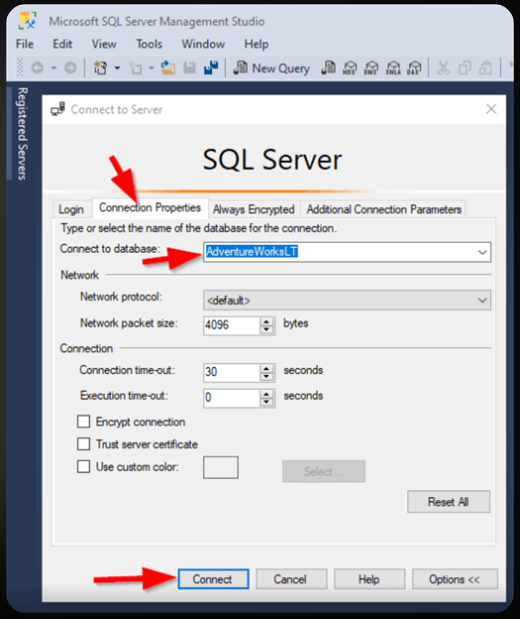
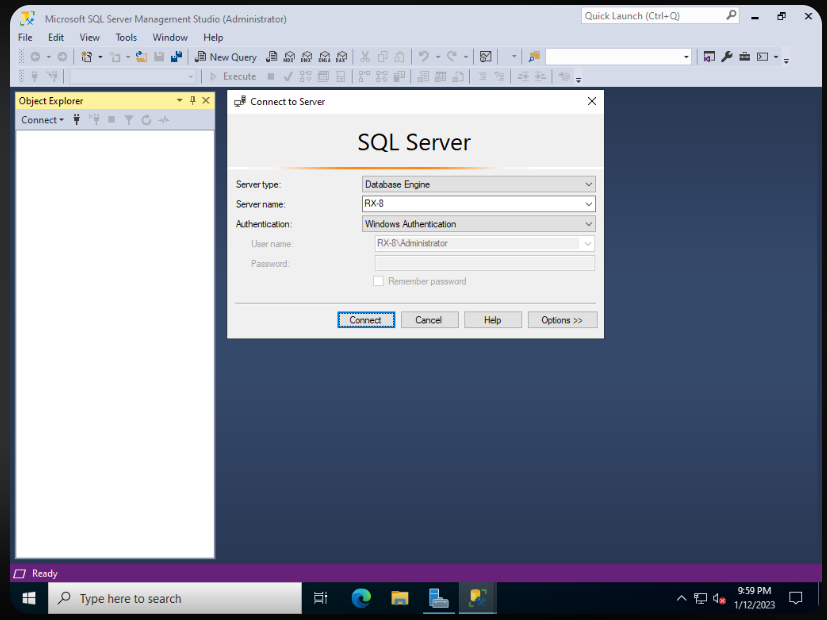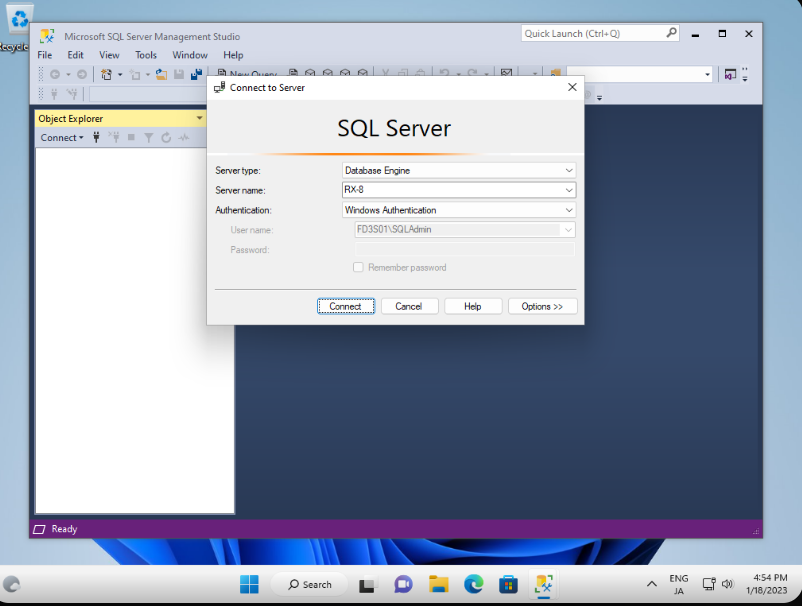

## 5. Object Explorer

The **Object Explorer** is the tree-view panel on the left side of SSMS — it's how you browse everything on the connected server: databases, tables, views, stored procedures, security settings, and server-level configuration, all organized hierarchically and expandable. Nearly every action in SSMS starts by navigating to the right node in this tree, then right-clicking for available actions (e.g., right-click **Databases** → **New Database...**).

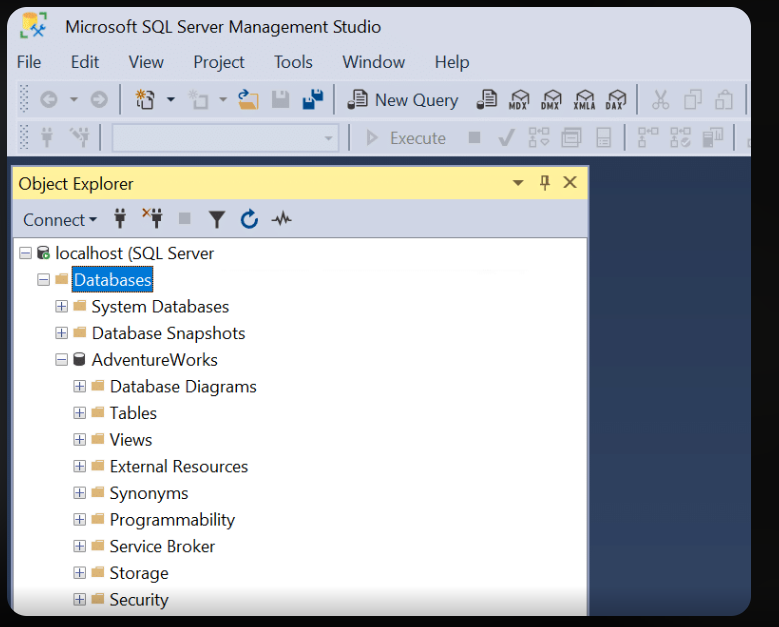

## 6. SQL Server Services

Because SQL Server runs as a **Windows Service** (Section 3), it can be started, stopped, or restarted independently of SSMS — through the **SQL Server Configuration Manager** or the Windows **Services** panel. This matters practically: if SQL Server's service isn't running, SSMS won't be able to connect to it at all, regardless of how the connection dialog is configured. Restarting the service is also the standard step after applying a Cumulative Update (Section 3), or after certain configuration changes that require the engine to reload.

## 7. Databases

Recall from Session 1: a **Database** is a collection of organized data. Within one running SQL Server instance, there can be — and typically are — many separate databases, each isolated from the others, each with its own tables, users, and settings. SQL Server organizes these into two categories: **System Databases** and **User-Defined Databases**.


## 8. System Databases

SQL Server automatically creates four **system databases** the moment it's installed — these support the engine's own internal operation, and normally shouldn't be modified directly:

| Database | Purpose |
|---|---|
| **Master** | Records system-level information for the entire SQL Server instance: all logins, all other databases, and server-wide configuration. If `Master` is damaged, SQL Server may not start at all. |
| **TempDB** | A workspace for temporary objects and intermediate results (temporary tables, sorting operations, etc.). It's recreated fresh every time SQL Server restarts. |
| **Model** | A template database. Every new database you create starts as a copy of `Model`'s structure — so any object added to `Model` is inherited by every future new database. |
| **MSDB** | Used by SQL Server Agent for scheduling jobs, alerts, and backup/restore history tracking. |

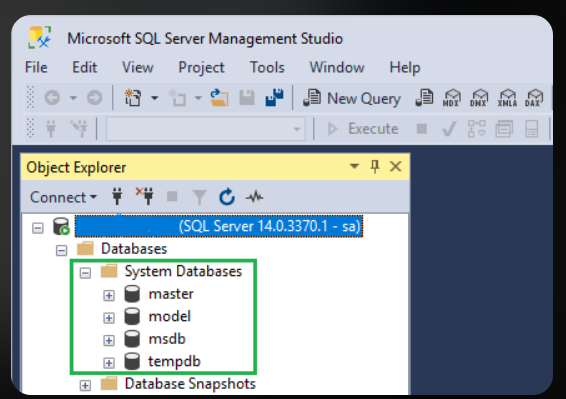

## 9. User-Defined Databases (UDD)

Everything beyond the four system databases — the databases *you* create for actual applications — falls under **User-Defined Databases**. Examples: a Human Resources system, a CRM, a financial accounting system, a loan management system.

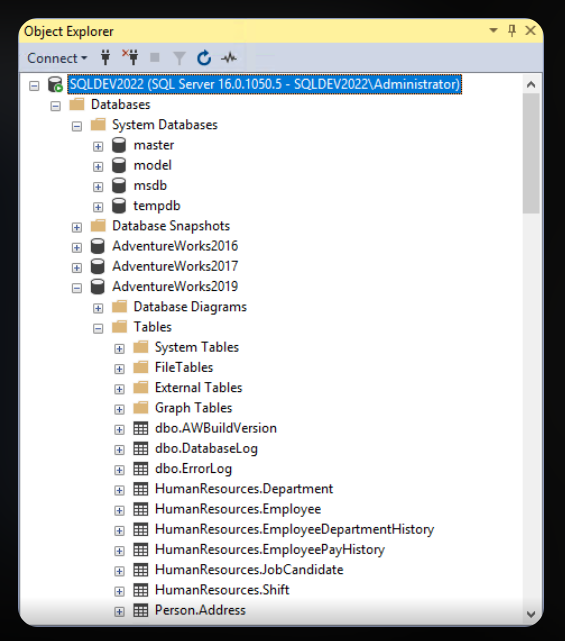

### Naming Convention

Choosing a consistent naming style matters for readability and team consistency. The common styles:

| Style | Example |
|---|---|
| **PascalCase** | `HumanResource` |
| **camelCase** | `humanResource` |
| **snake_case** | `human_resource` |
| **Hungarian Notation** | `HR`, `hr` (short, prefix-style abbreviations) |

**Convention used for database names in this course: PascalCase.**

Some worked examples, going from a business description to a final database name:

- A Human Resources system → **`HumanResource`**
- A Customer Relationship Management system → **`CustomerRelationshipManagement`** (or the common abbreviation, **`CRM`**)
- "Sematec's Learning Management System" (سامانه مدیریت آموزش سماتک) → **`SematecLearningManagementSystem`**, commonly shortened to **`SematecLMS`**

Note how the same underlying name can be expressed several different ways depending on the convention chosen (`SematecLearningManagementSystem` vs. `Sematec_LMS` vs. `sematec_learning_management_system`) — what matters most isn't which style you pick, but **applying it consistently** across every database and object in your system.


## 10. Database Files: `.mdf`, `.ndf`, `.ldf`

Every SQL Server database is physically stored using two categories of files: **Data Files** and a **Log File**.

### Data Files

| File Type | Extension | Role |
|---|---|---|
| **Primary Data File** | `.MDF` (Master Data File) | Every database has **exactly one**. It's the main data file, and also stores pointers to any other files belonging to the database. |
| **Secondary Data File** | `.NDF` (Non-Master Data File) | **Optional.** Used when a database's data is large enough to benefit from being split across multiple physical files — useful for spreading data across multiple disks for performance, or simply for very large databases. |

### Log File

| File Type | Extension | Role |
|---|---|---|
| **Log File** | `.LDF` (Log Data File) | Records every change made to the database (see DML/DDL below) *before* it's committed to the data files — this is what enables recovery after a crash and supports transactional rollback. |

### File Count and Size Limits

| Rule | Limit |
|---|---|
| Every database requires **exactly one** `.MDF` file | — |
| Maximum `.NDF` (secondary data) files per database | 32,765 |
| Maximum `.LDF` (log) files per database | 32,766 |
| Maximum size of a single Data File (`.MDF` or `.NDF`) | 16 TB |
| Maximum size of a single Log File (`.LDF`) | 2 TB |
| **Best Practice** | Use **only one** log file per database, even though up to 32,766 are technically allowed — multiple log files don't improve performance the way multiple data files can, and add unnecessary complexity |

### A Quick Refresher on the Units Behind These Limits

The storage limits above (16 TB, 2 TB) are built from the standard binary unit progression, worth having memorized:

```text
1 bit            → a single 0 or 1
8 bits           → 1 byte
1024 bytes       → 1 KB (Kilobyte)
1024 KB          → 1 MB (Megabyte)
1024 MB          → 1 GB (Gigabyte)
1024 GB          → 1 TB (Terabyte)
1024 TB          → 1 PB (Petabyte)
```

The theoretical combined maximum for a single SQL Server database, across all its data files, works out to roughly **524 PB** — a ceiling essentially no real-world database ever approaches, but it illustrates how much headroom SQL Server's file architecture is designed to support.

### Storage Pages

Internally, SQL Server organizes all data into fixed-size blocks called **pages**, each exactly **8 KB**. Every table's rows are physically stored across these 8 KB pages — this is the fundamental unit SQL Server reads and writes at, underneath the `.MDF`/`.NDF` files described above.
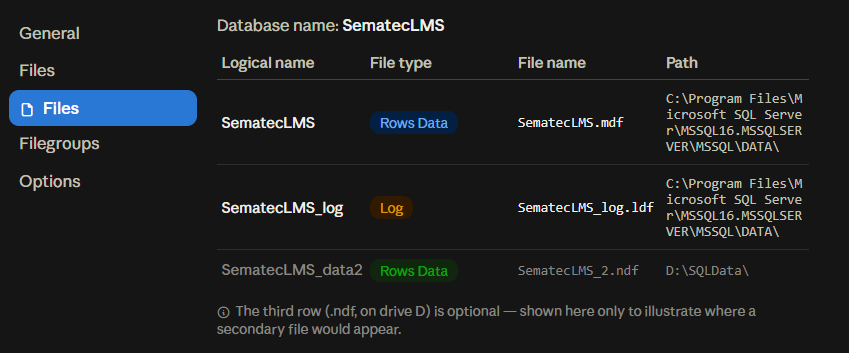

### What Is a Filegroup?

Before the individual columns — a step back. A **Filegroup** is an organizational layer sitting between the database and its physical data files: it groups one or more data files (`.mdf` / `.ndf`) under a single name. Every database has at least one Filegroup called **`PRIMARY`**, and the `.mdf` file always belongs to it.

### The Columns on the Filegroups Page

### The "Rows" Section (the one you'll always see)

| Column | Meaning |
|---|---|
| **Name** | The Filegroup's name — defaults to `PRIMARY`, but you can create additional Filegroups (e.g., `SECONDARY`) |
| **Files** | How many data files (`.mdf`/`.ndf`) belong to this Filegroup — e.g., if you have both the `.mdf` and one `.ndf` grouped together, this shows `2` |
| **Read-only** | If checked, nobody can modify data stored in this Filegroup — it becomes read access only. Commonly used for archival/historical data that no longer changes |
| **Default** | Determines which Filegroup SQL Server automatically uses when you create a new table without explicitly specifying one — this defaults to `PRIMARY` unless you change it |

### The Other Two Sections (usually empty)

- **Filestream** — a special kind of Filegroup for storing large binary files (images, videos, PDFs) as actual files on disk, while still being managed by SQL Server — only relevant if your database needs to store large binary content
- **In-Memory OLTP** — a special Filegroup for **memory-optimized tables**, which keep part of their data in RAM instead of on disk for very high-speed access — an advanced feature used only in systems with demanding performance requirements

### Why Create Additional Filegroups at All? (Practical Use Cases)

For a small database like the ones built in this course, you'll rarely need more than `PRIMARY` — everything just stays there. But in larger, real-world projects, Filegroups are used for:

- **Spreading data across multiple disks** — e.g., putting high-traffic tables on a fast SSD, and archival tables on cheaper storage
- **Partial backups** — you can back up a single Filegroup instead of the entire database
- **Making old data read-only** — e.g., putting last year's orders, which no longer change, into their own read-only Filegroup/

- ### Separate Filegroups for Data and Index — Two Reasons, Combined

There are actually two independent justifications for splitting Data and Index into separate Filegroups — the performance angle covered earlier, and your professor's angle: **disaster recovery**. Both are valid, and in real systems they reinforce each other. Let's walk through both, with the professor's reasoning explained in full.

### The Core Idea Behind Your Professor's Point: An Index Is Reconstructible, Data Is Not

This is the key distinction:

```text
Data   → the actual information. If it's lost, it's genuinely gone — there's no other source for it.
Index  → just a helper structure built ON TOP OF the data, to make searching faster.
         If it's lost, it can be rebuilt from scratch (REBUILD INDEX) — as long as the underlying
         Data is intact.
```

In other words, an Index isn't something you truly "lose" in the same sense as Data — it can always be regenerated at any time, on demand, provided the Data it was built from is still there.

### Why That Difference Leads to Separate Filegroups

If Data and Index sit in the **same** Filegroup and something physically damages it (disk failure, corruption), you have to restore **everything** from backup — Data *and* Index together. That's wasteful for two reasons: restoring the Index takes real time, and it inflates your backup size unnecessarily (indexes can sometimes take up nearly as much space as the data they're built from).

But if they're **separated**:

```text
If only Index_FileGroup is damaged:
   → No need to restore from backup at all
   → Just run REBUILD INDEX, and the indexes are regenerated from the healthy Data
   → Much faster than restoring a backup file

If Data_FileGroup is damaged:
   → This is the part that's genuinely critical and must be restored from backup
   → But since the Index is separate, you don't have to wait for it to be restored too
```

### The Practical Payoff: Piecemeal Restore

Large systems support a capability called **Piecemeal Restore** — the ability to restore just one specific Filegroup and bring the rest back later, while the database is already partially usable in the meantime.

With `Data_FileGroup` and `Index_FileGroup` separated:

1. Restore `Data_FileGroup` first — quickly — so users can access the actual data right away (possibly slower without indexes, but functional).
2. Restore or rebuild `Index_FileGroup` afterward, without urgency, since the critical part is already back online.

The practical result: **downtime shrinks**, because you're no longer waiting on a full restore before the system becomes usable again — only on restoring the part that genuinely can't be regenerated.

### Comparison Table

| Scenario | Shared Filegroup | Separate Filegroups |
|---|---|---|
| Index gets corrupted | Entire Filegroup (including Data) must be restored from backup | Just run `REBUILD INDEX` — fast, no backup needed |
| Data gets corrupted | Full restore, indexes included | Restore only `Data_FileGroup`, then rebuild the Index afterward |
| Backup size | Larger (indexes included every time) | `Index_FileGroup` can be backed up less frequently, since it's reconstructible anyway |
| Recovery time | Longer | Shorter, since the critical part (Data) comes back first |


  

## 11. What Actually Gets Written to the Log File: DML vs. DDL

The `.LDF` log file (Section 10) records changes made through two categories of SQL commands:

| Category | Full Name | Commands | Purpose |
|---|---|---|---|
| **DML** | Data Manipulation Language | `INSERT`, `UPDATE`, `DELETE` (and `SELECT`, which doesn't modify data but reads it) | Working with the *data* stored inside tables |
| **DDL** | Data Definition Language | `CREATE`, `ALTER`, `DROP` | Working with the *structure* of the database itself — tables, columns, constraints |

Every DML and DDL operation that changes the database gets recorded in the log file first, which is precisely why the log file exists and why its integrity matters as much as the data files themselves.


# Filegroups in Practice — Separating Metadata, Data, and Index نکته مهم+++



This continues directly from the Files/Filegroups discussion: by default, everything — system metadata *and* your actual table data — lands in `PRIMARY` (the `.mdf` file), because `PRIMARY` starts out as the **Default Filegroup**. The goal here is to separate:

```text
PRIMARY (.mdf)        → stays lean, holds only SQL Server's own system metadata
Data_FileGroup (.ndf)  → holds all actual table data
Index_FileGroup (.ndf) → holds all indexes
```

This keeps the hardest-to-lose file (`PRIMARY`, holding core system structure) minimal and well-protected, while the bulk of data and indexes live in their own separately-manageable files — tying back to the disaster-recovery reasoning from before: an Index can always be rebuilt from Data, so it doesn't need the same level of protection.

## Step 1: Create the Two New Filegroups

In [ ]:
-- T-SQL (SQL Server) — run in SSMS Query Editor, not this Python kernel

ALTER DATABASE SematecLMS ADD FILEGROUP Data_FileGroup;
ALTER DATABASE SematecLMS ADD FILEGROUP Index_FileGroup;

## Step 2: Add a `.ndf` File to Each Filegroup

Creating a Filegroup alone doesn't create physical storage — it needs at least one file assigned to it.

In [ ]:
ALTER DATABASE SematecLMS
ADD FILE (
    NAME = SematecLMS_Data,
    FILENAME = 'C:\SQLData\SematecLMS_Data.ndf',
    SIZE = 256MB,
    FILEGROWTH = 64MB
) TO FILEGROUP Data_FileGroup;

ALTER DATABASE SematecLMS
ADD FILE (
    NAME = SematecLMS_Index,
    FILENAME = 'C:\SQLData\SematecLMS_Index.ndf',
    SIZE = 128MB,
    FILEGROWTH = 64MB
) TO FILEGROUP Index_FileGroup;

## Step 3: The Key Step — Change the Default Filegroup

This is the part that actually redirects new tables away from `PRIMARY`. Only one Filegroup can be Default at a time — setting a new one automatically un-sets the previous one.

In [ ]:
ALTER DATABASE SematecLMS MODIFY FILEGROUP Data_FileGroup DEFAULT;

**Effect of this one line:**

```text
Before:  CREATE TABLE ... (no filegroup specified)  →  lands in PRIMARY (.mdf)
After:   CREATE TABLE ... (no filegroup specified)  →  lands in Data_FileGroup (.ndf)
```

`PRIMARY` is no longer the Default — it now holds only what SQL Server itself needs, and stays that way going forward without any extra effort on every table you create.

## Step 4: Creating a Table Now (No Change Needed)

Because `Data_FileGroup` is now Default, an ordinary `CREATE TABLE` with no `ON` clause automatically goes to the right place:


In [ ]:
CREATE TABLE Student (
    StudentID INT PRIMARY KEY,
    StudentName VARCHAR(100) NOT NULL
);
-- No "ON Data_FileGroup" needed — it's automatic now that Data_FileGroup is Default

## Step 5: Indexes Still Need to Be Explicit

This is the one place the Default rule does **not** save you effort. Since `Index_FileGroup` isn't Default, an index created without an explicit `ON` clause would *also* follow the Default rule and land in `Data_FileGroup` — right alongside the table data, defeating the whole separation.

In [ ]:
-- WRONG — this index would silently land in Data_FileGroup, not Index_FileGroup
CREATE INDEX IX_Student_Name ON Student(StudentName);

-- CORRECT — explicitly place the index in Index_FileGroup
CREATE INDEX IX_Student_Name
ON Student(StudentName)
ON Index_FileGroup;

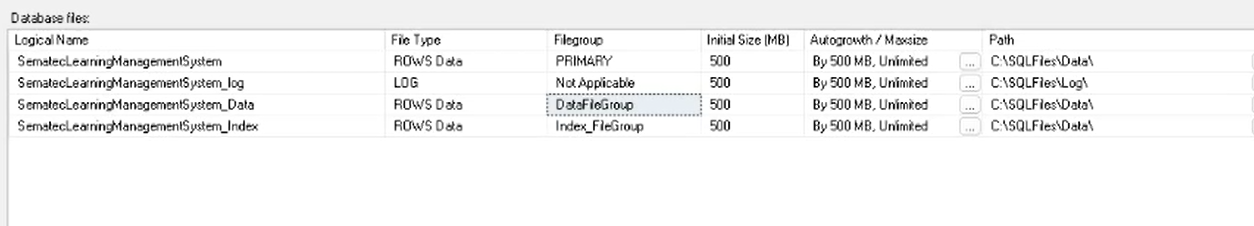

## 12. Creating a Database

In SSMS, there are two equivalent ways to create a database:

**Graphical method:**
1. In Object Explorer, right-click **Databases** → **New Database...**
2. Enter a name (following the PascalCase convention from Section 9)
3. Optionally configure file locations, initial size, and growth settings
4. Click **OK**

**SQL method** (in the Query Editor, covered next):
```sql
CREATE DATABASE SematecLMS;
```

Both approaches produce the same result — the graphical method is friendlier while learning; writing `CREATE DATABASE` directly becomes the standard approach once you're comfortable with SQL.

## 13. Creating a Table

Once a database exists, tables are created within it, following the same two-path pattern:

**Graphical method:** Object Explorer → expand the database → right-click **Tables** → **New Table...**, then define columns, data types, and keys visually.

**SQL method:**
```sql
CREATE TABLE Employee (
    EmployeeCode INT PRIMARY KEY,
    EmployeeName VARCHAR(100) NOT NULL
);
```

This is the direct SQL implementation of the Logical Design concepts from earlier sessions (Primary Keys, Foreign Keys, data types) — SSMS is simply the interface you use to actually execute this `CREATE TABLE` statement against a real, running database.

## 14. Query Editor and Running SQL Queries

The **Query Editor** is SSMS's SQL-writing workspace — opened via **New Query** (toolbar button, or right-click a database → **New Query**). It's where all the `CREATE`, `INSERT`, `SELECT`, and other SQL statements from this entire course actually get typed and executed against a real database.

**To run a query:** write your SQL statement(s) in the editor, then either click **Execute** on the toolbar or press **F5**. Results (for a `SELECT`) appear in a grid below the editor; for `CREATE`/`INSERT`/`UPDATE`/`DELETE`, a confirmation message appears instead ("Command(s) completed successfully").

# Step_By_Step
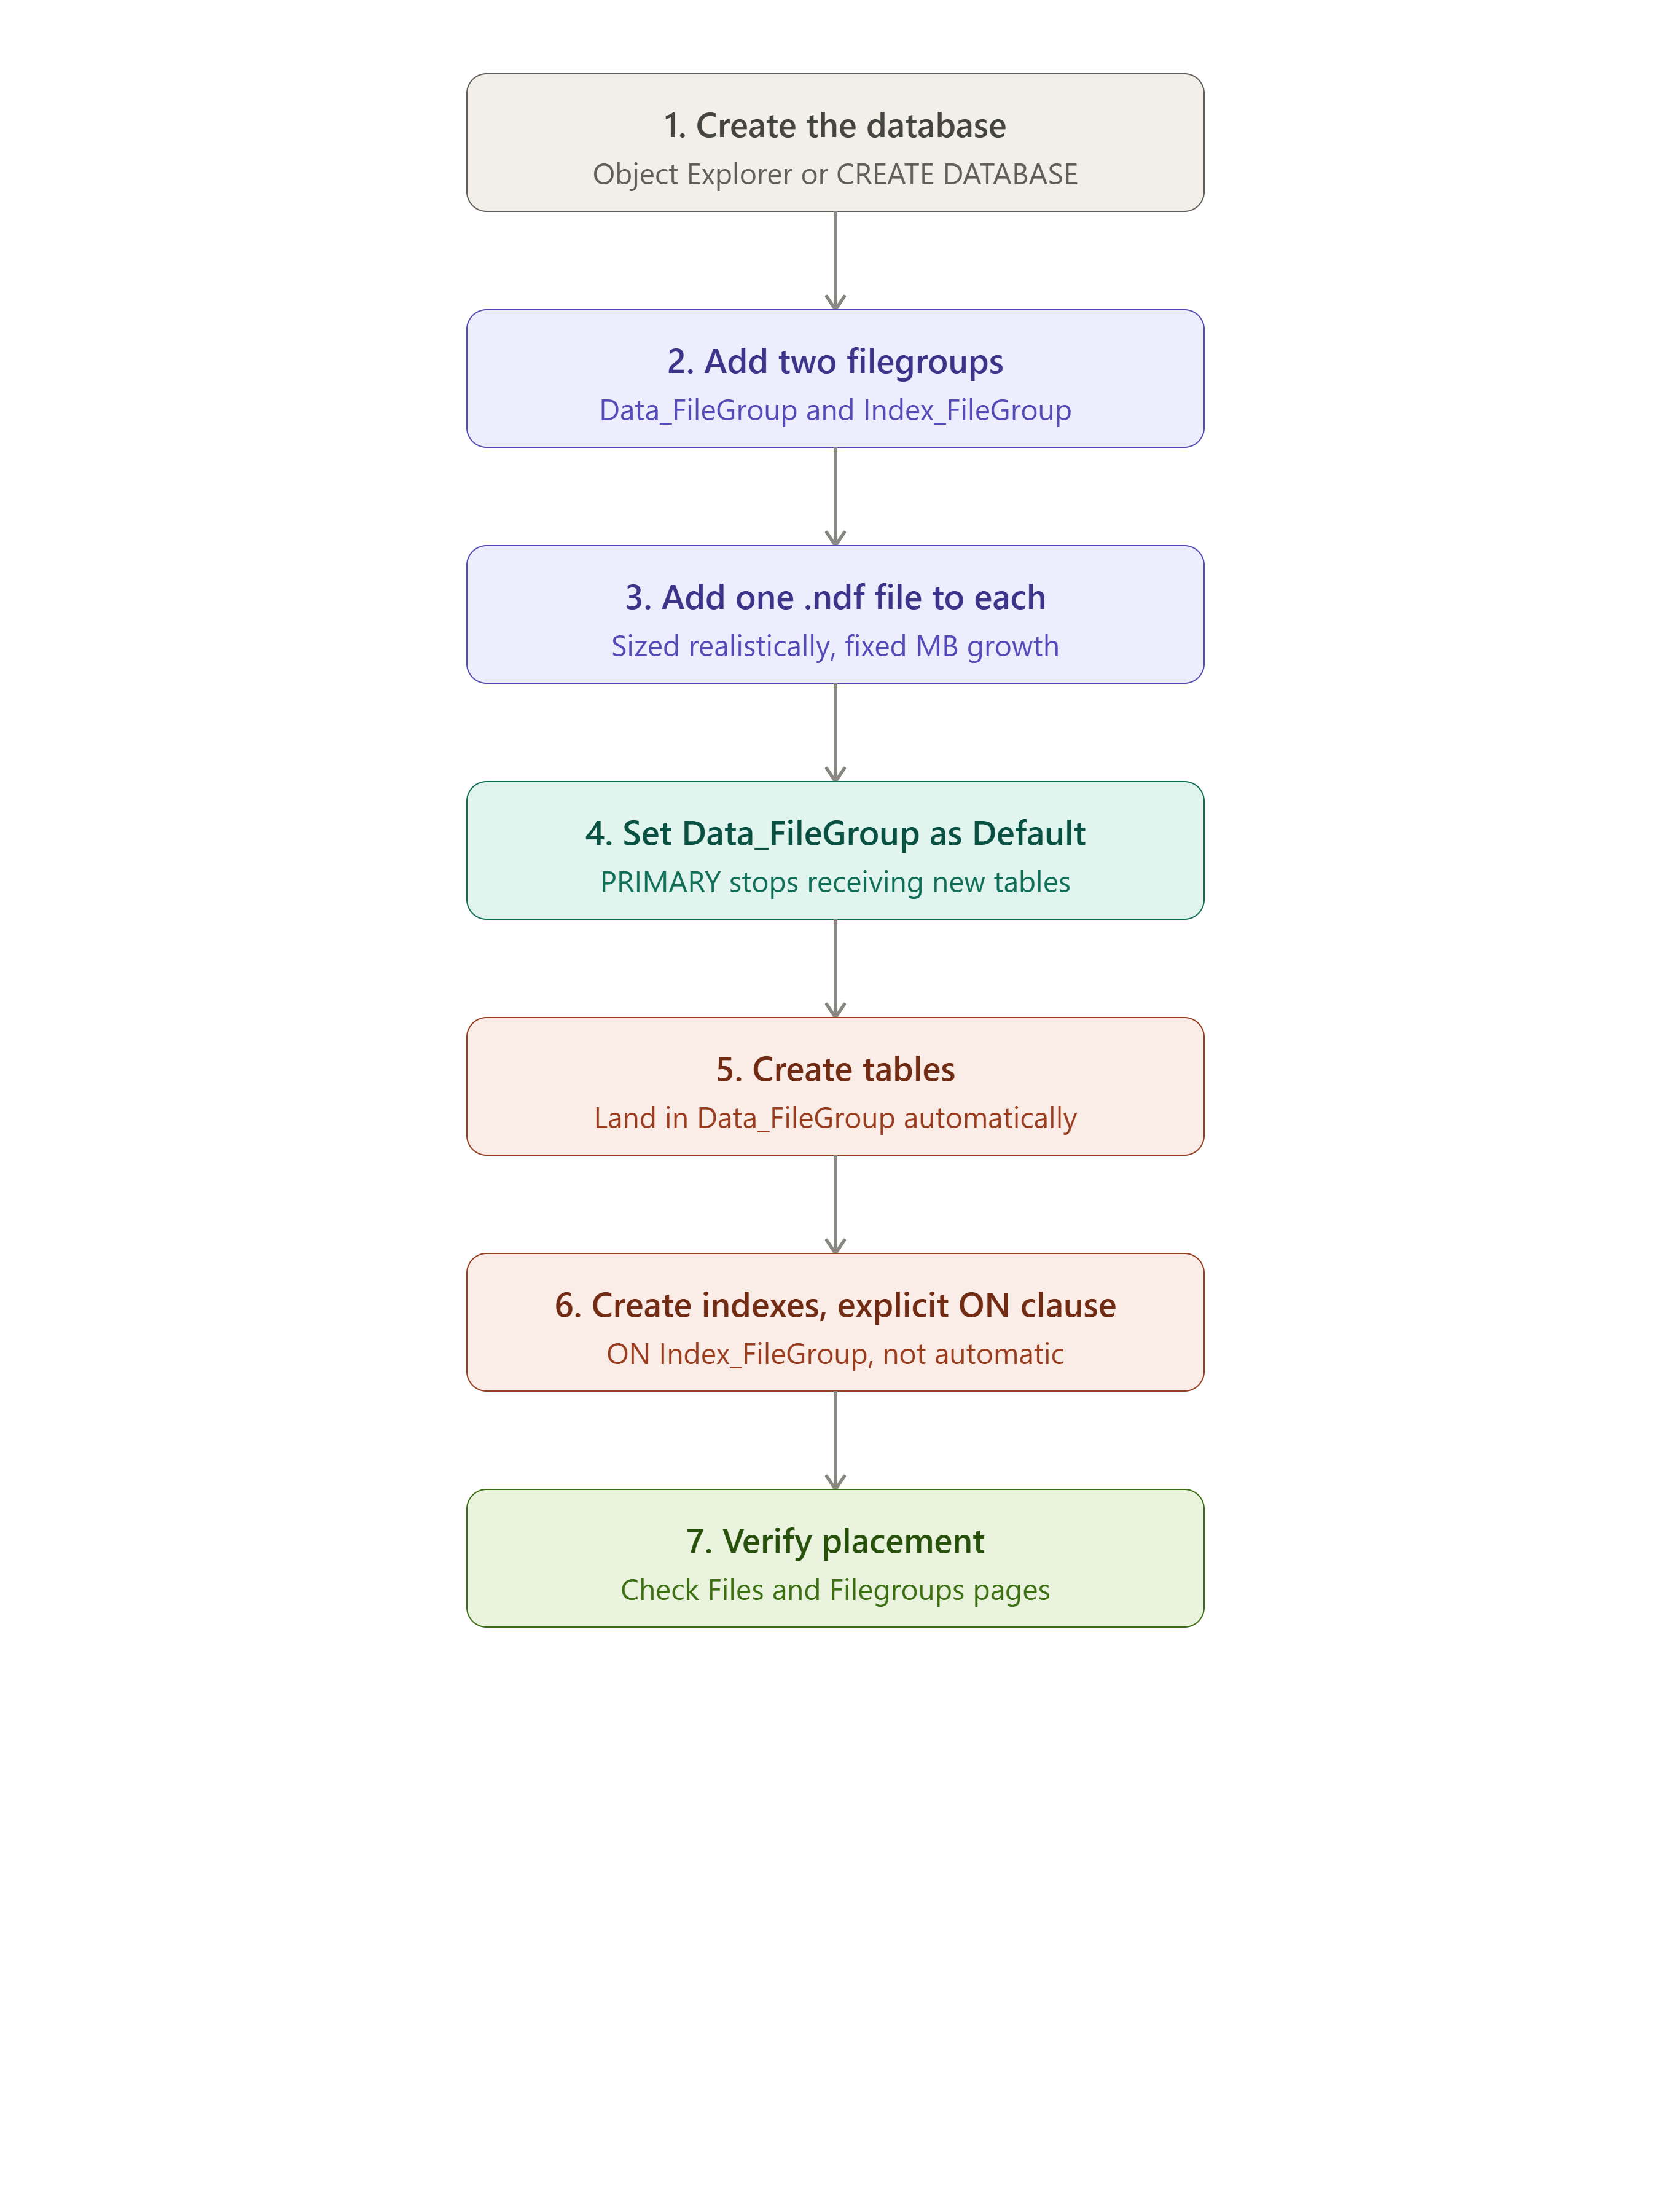